# 01 — Exploratory Data Analysis

**Goriška Brda Harvest Prediction App**

Purpose of this notebook:
1. Understand the shape, types, and quality of the dataset.
2. Understand the two prediction targets: `harvest_category` (classification) and `yield_kg_ha` (regression).
3. Identify **data leakage** risks — columns that look predictive but are actually
   computed from (or only knowable after) the outcome we're trying to predict.
4. Propose a safe feature set for Phase 2 (cleaning & feature engineering).

Nothing here trains a model — this is inspection only.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent / "src"))
from data import load_dataset

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = load_dataset()
df.shape


(2176, 38)

## 1. Structure and data quality


In [2]:
df.dtypes


year                       int64
grape_variety                str
grape_color                  str
location                     str
soil_type                    str
elevation_m                int64
vine_age_years             int64
vintage_age_years          int64
avg_temperature_C        float64
min_spring_temp_C        float64
growing_season_temp_C    float64
temp_deviation_C         float64
summer_heat_days           int64
spring_frost_days          int64
growing_degree_days        int64
annual_rainfall_mm         int64
winter_rainfall_mm         int64
spring_rainfall_mm         int64
summer_rainfall_mm         int64
autumn_rainfall_mm         int64
harvest_rainfall_mm        int64
rainfall_deviation_mm      int64
humidity_pct             float64
sunshine_hours             int64
soil_moisture_pct        float64
heat_frost_ratio         float64
prev_harvest_doy           int64
prev_yield_kg_ha         float64
gbai_score               float64
ln_quality_index         float64
est_price_

In [3]:
# Panel structure check: is this one row per (location, year, grape_variety)?
n_locations = df["location"].nunique()
n_years = df["year"].nunique()
n_varieties = df["grape_variety"].nunique()
print(f"locations={n_locations}, years={n_years}, varieties={n_varieties}")
print(f"locations x years x varieties = {n_locations * n_years * n_varieties}")
print(f"actual rows = {len(df)}")


locations=8, years=34, varieties=8
locations x years x varieties = 2176
actual rows = 2176


The dataset is a **fully balanced panel**: one row per (location, year, grape_variety)
combination, with no gaps. This is a strong signal the dataset was simulated rather than
collected from messy real-world records — worth stating explicitly as a limitation in the
final report (real vineyard records would have irregular coverage, missing years, etc.).


In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
humidity_pct,73,3.35
min_spring_temp_C,62,2.85
soil_moisture_pct,57,2.62
prev_yield_kg_ha,56,2.57


Missingness is small (under 3.5% per column) and concentrated in four columns:
`min_spring_temp_C`, `humidity_pct`, `soil_moisture_pct`, `prev_yield_kg_ha`.
This looks like injected/realistic missingness rather than a structural problem — it will
need imputation in Phase 2, not row-dropping (dropping ~3% of rows across four independent
columns would compound to a meaningful, avoidable data loss).


## 2. The two prediction targets


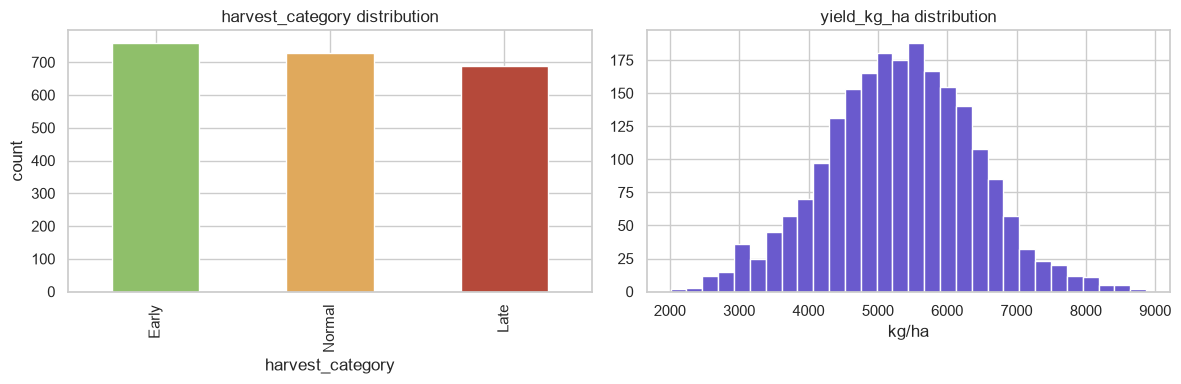

harvest_category
Early     759
Normal    728
Late      689
Name: count, dtype: int64

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["harvest_category"].value_counts().reindex(["Early", "Normal", "Late"]).plot(
    kind="bar", ax=axes[0], color=["#8fbf6a", "#e0a95c", "#b5493a"]
)
axes[0].set_title("harvest_category distribution")
axes[0].set_ylabel("count")

axes[1].hist(df["yield_kg_ha"], bins=30, color="#6a5acd", edgecolor="white")
axes[1].set_title("yield_kg_ha distribution")
axes[1].set_xlabel("kg/ha")

plt.tight_layout()
plt.show()

df["harvest_category"].value_counts()


In [6]:
df["yield_kg_ha"].describe()


count    2176.000000
mean     5323.097426
std      1086.655382
min      2010.000000
25%      4610.000000
50%      5340.000000
75%      6050.000000
max      8870.000000
Name: yield_kg_ha, dtype: float64

`harvest_category` is reasonably balanced (759 / 728 / 689) — good news for classification:
plain accuracy will be a meaningful metric alongside macro-F1, and we won't need class
reweighting just to get sane results. `yield_kg_ha` is unimodal and roughly symmetric
(mean 5,323 kg/ha, std 1,087), suitable for regression without a log transform.


## 3. Leakage check #1 — `harvest_category` is a deterministic bucket of `harvest_doy`


In [7]:
df.groupby("harvest_category")["harvest_doy"].agg(["min", "max", "mean", "count"])


,min,max,mean,count
harvest_category,,,,
Early,238,258,251.098814,759
Late,269,298,275.943396,689
Normal,259,268,263.364011,728


The day-of-year ranges **do not overlap** between categories (Early ≤ 258, Normal 259–268,
Late ≥ 269). `harvest_category` is literally computed by bucketing `harvest_doy` — it is
not an independent measurement.

**Consequence:** `harvest_doy` (and its calendar form, `harvest_date`) must be excluded
from the feature set entirely. Including either would let the classifier "cheat" by
reading off the answer, producing near-100% accuracy offline while being useless in
production (the app doesn't know the harvest date — predicting it *is* the task).


## 4. Leakage check #2 — `yield_category` is a deterministic bucket of `yield_kg_ha`


In [8]:
df.groupby("yield_category")["yield_kg_ha"].agg(["min", "max", "mean", "count"])


,min,max,mean,count
yield_category,,,,
High,5810,8870,6495.730028,726
Low,2010,4870,4140.164384,730
Medium,4880,5800,5340.055556,720


Same pattern: Low ≤ 4,870, Medium 4,880–5,800, High ≥ 5,810 — clean non-overlapping
thresholds. `yield_category` must be excluded as a feature for the same reason as above.
It's not used as a target either since the assignment specifies `yield_kg_ha` (regression),
but it's worth confirming it isn't accidentally used as an input.


## 5. Leakage check #3 — post-harvest quality/economic indices


In [9]:
suspects = ["gbai_score", "ln_quality_index", "est_price_eur"]
df[suspects + ["yield_kg_ha"]].corr()["yield_kg_ha"].sort_values(ascending=False)


yield_kg_ha         1.000000
ln_quality_index    0.654781
gbai_score          0.618916
est_price_eur       0.513440
Name: yield_kg_ha, dtype: float64

In [10]:
df.groupby("vintage_quality")["yield_kg_ha"].mean().sort_values()


vintage_quality
Poor           4253.740876
Average        5278.296296
Good           5736.277372
Exceptional    6033.796296
Name: yield_kg_ha, dtype: float64

`gbai_score`, `ln_quality_index`, and `est_price_eur` correlate strongly with `yield_kg_ha`
(r = 0.62–0.65), and `vintage_quality` shows a clean monotonic relationship (Poor → 4,254
kg/ha, Exceptional → 6,034 kg/ha). These read as **quality/price scores computed after the
harvest outcome is known** — a vintage can't be scored "Exceptional" before it has actually
happened. Using them as features would leak the outcome through a back door, even though
none of them literally equals the target.

**Consequence:** exclude `gbai_score`, `ln_quality_index`, `est_price_eur`, and
`vintage_quality` from the feature set.

`climate_risk` is a related case — see next section.


In [11]:
df.groupby("climate_risk")["yield_kg_ha"].mean().sort_values()


climate_risk
High      4836.661932
Medium    5088.352273
Low       5984.179688
Name: yield_kg_ha, dtype: float64

`climate_risk` also correlates with yield, but less cleanly than the columns above, and its
exact construction is unknown (it may be a rule-based summary of weather deviations we
already have as raw columns, rather than something computed from the outcome). Given the
ambiguity, the safe choice for Phase 2 is to **exclude it from the ML feature set** too. It
may still be useful later as a **rule-based, non-ML display field** on the Prediction page
(the assignment's "Climate Risk" / "Main Risk Factor" output) — that's a product decision
to revisit once the models exist, not a reason to feed an unverified derived label into
the model now.


## 6. Leakage check #4 — features that can't exist before harvest happens


In [12]:
df[["harvest_rainfall_mm", "autumn_rainfall_mm"]].describe()


,harvest_rainfall_mm,autumn_rainfall_mm
count,2176.000000,2176.000000
mean,204.617647,284.764706
std,26.935307,38.098478
min,158.000000,221.000000
25%,187.000000,260.000000
50%,208.500000,284.000000
75%,223.000000,305.000000
max,277.000000,394.000000


This one isn't about correlation — it's about **timing**. `harvest_rainfall_mm` is, by its
own name, rainfall recorded during the harvest window. The harvest window is only known
*after* we know `harvest_category`/`harvest_doy` — so this column cannot be known at
prediction time, for the same reason `harvest_doy` can't.

`autumn_rainfall_mm` is a softer version of the same problem: Goriška Brda harvests happen
within September–October (day-of-year 238–298 in this data), which overlaps most of what
"autumn" covers. For a Normal/Late harvest, part or all of the autumn rainfall total would
be measured *after* the harvest already happened.

There's also a production-level reason to exclude both, independent of the statistical
leakage argument: at prediction time the backend calls the **Open-Meteo forecast API** for
*current* conditions. It cannot return a full-season rainfall total for a season that
hasn't finished yet. Any feature that isn't obtainable from a forecast call at the moment
a user asks for a prediction is unusable in production, regardless of how it looks in the
historical dataset.

**Consequence:** exclude `harvest_rainfall_mm` and `autumn_rainfall_mm`.


In [13]:
# Does the same timing problem affect annual_rainfall_mm? If it's a full Jan-Dec total for
# the harvest year, it necessarily includes rainfall recorded after a September/October
# harvest already happened - same issue as autumn_rainfall_mm, just diluted.
rainfall_cols = [
    "winter_rainfall_mm", "spring_rainfall_mm", "summer_rainfall_mm",
    "autumn_rainfall_mm", "annual_rainfall_mm", "harvest_rainfall_mm",
]
df[rainfall_cols + ["harvest_doy"]].corr()["harvest_doy"].drop("harvest_doy").sort_values(key=abs, ascending=False)


spring_rainfall_mm     0.211447
harvest_rainfall_mm    0.165290
annual_rainfall_mm     0.156080
summer_rainfall_mm     0.124464
autumn_rainfall_mm     0.102407
winter_rainfall_mm     0.045182
Name: harvest_doy, dtype: float64

`annual_rainfall_mm` correlates with `harvest_doy` almost as strongly as
`autumn_rainfall_mm` and `harvest_rainfall_mm` do — far more than the individual
winter/spring/summer totals. That's consistent with it being a Jan–Dec sum that partially
consists of rainfall recorded *after* the harvest event for that same year, i.e. the same
timing leak, just diluted by three clean seasons' worth of data.

**Consequence:** exclude `annual_rainfall_mm` as well. `winter_rainfall_mm`,
`spring_rainfall_mm`, and `summer_rainfall_mm` show no such pattern and safely precede any
possible harvest date in this data (harvest never occurs before day-of-year 238, i.e.
late August) — keep those three.


## 7. Redundant / degenerate columns


In [14]:
df.groupby("grape_variety")["grape_color"].unique()


grape_variety
Cabernet Sauvignon      [Red]
Chardonnay            [White]
Malvazija             [White]
Merlot                  [Red]
Pinot Grigio          [White]
Pinot Noir              [Red]
Rebula                [White]
Sauvignon Blanc       [White]
Name: grape_color, dtype: object

In [15]:
df["vine_age_years"].corr(df["vintage_age_years"])


np.float64(-0.014243867076450988)

In [16]:
df.groupby("year")["vintage_age_years"].first().head()


year
1991    34
1992    33
1993    32
1994    31
1995    30
Name: vintage_age_years, dtype: int64

Two more columns to drop, for different reasons:

- **`grape_color`** is 100% determined by `grape_variety` (each variety maps to exactly one
  color). Keeping both adds no information, just redundant dimensionality — drop
  `grape_color`, keep `grape_variety`.
- **`vintage_age_years`** is essentially constant within a year (e.g. every 1991 row = 34)
  and near-zero correlated with `vine_age_years` (r ≈ -0.01). It looks like
  `reference_year − year` — i.e. "how long ago was this vintage", computed relative to
  whenever the dataset was built. That's meaningless for prediction: at request time we're
  forecasting a *current or future* vintage, so this quantity would be ~0 and carries no
  real signal beyond `year` itself, which we already keep. Drop it.


## 8. `prev_harvest_doy` / `prev_yield_kg_ha` — legitimate lag features, not leakage


In [17]:
# Verify these are genuine previous-year values for the same location+variety,
# not something computed from the current row's outcome.
sample = df[(df["location"] == "Dobrovo") & (df["grape_variety"] == "Rebula")].sort_values("year")
sample[["year", "harvest_doy", "yield_kg_ha", "prev_harvest_doy", "prev_yield_kg_ha"]].head(6)


,year,harvest_doy,yield_kg_ha,prev_harvest_doy,prev_yield_kg_ha
0,1991,272,4640,269,6500.0
64,1992,271,3270,272,4640.0
128,1993,269,5530,271,3270.0
192,1994,271,3960,269,5530.0
256,1995,267,5010,271,3960.0
320,1996,266,5410,267,5010.0


`prev_harvest_doy` and `prev_yield_kg_ha` for a given row match the *actual* `harvest_doy`
and `yield_kg_ha` of the same location+variety in the **previous year** — confirmed by
lining rows up chronologically above (e.g. 1992's `prev_yield_kg_ha` = 1991's
`yield_kg_ha`). This is a real historical fact a winery would know before the current
season's harvest (last year already happened), so it's a legitimate predictive feature —
not leakage.

It does carry some of the missing values noted in section 1 (e.g. 1997 is missing
`prev_yield_kg_ha` even though 1996's yield exists) — real record-keeping gaps happen, and
we'll impute rather than drop.


## 9. Candidate safe features vs. the targets


In [18]:
safe_numeric = [
    "elevation_m", "vine_age_years", "avg_temperature_C", "min_spring_temp_C",
    "growing_season_temp_C", "temp_deviation_C", "summer_heat_days", "spring_frost_days",
    "growing_degree_days", "winter_rainfall_mm", "spring_rainfall_mm",
    "summer_rainfall_mm", "rainfall_deviation_mm", "humidity_pct", "sunshine_hours",
    "soil_moisture_pct", "heat_frost_ratio", "prev_harvest_doy", "prev_yield_kg_ha",
]

corr = df[safe_numeric + ["yield_kg_ha"]].corr()["yield_kg_ha"].drop("yield_kg_ha")
corr.sort_values(key=abs, ascending=False)


spring_frost_days       -0.726903
heat_frost_ratio         0.535241
prev_yield_kg_ha         0.465168
summer_heat_days         0.348994
sunshine_hours          -0.247686
prev_harvest_doy        -0.198272
vine_age_years          -0.193463
spring_rainfall_mm      -0.192295
humidity_pct             0.119179
soil_moisture_pct       -0.100790
min_spring_temp_C        0.057695
rainfall_deviation_mm   -0.057580
temp_deviation_C         0.032188
growing_season_temp_C    0.032188
avg_temperature_C        0.032188
growing_degree_days      0.032123
summer_rainfall_mm      -0.026576
winter_rainfall_mm       0.022895
elevation_m              0.007923
Name: yield_kg_ha, dtype: float64

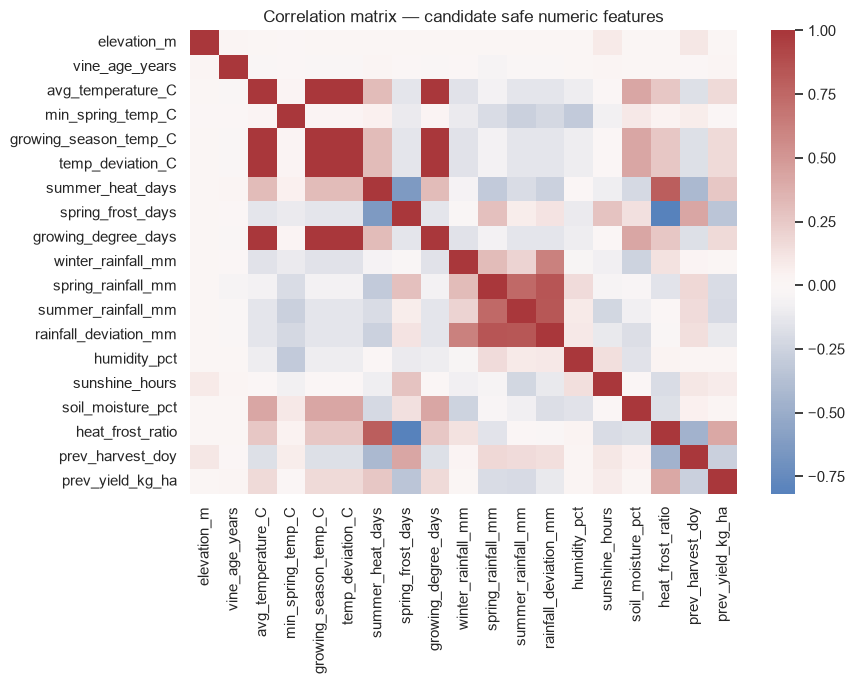

In [19]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[safe_numeric].corr(), cmap="vlag", center=0, annot=False)
plt.title("Correlation matrix — candidate safe numeric features")
plt.tight_layout()
plt.show()


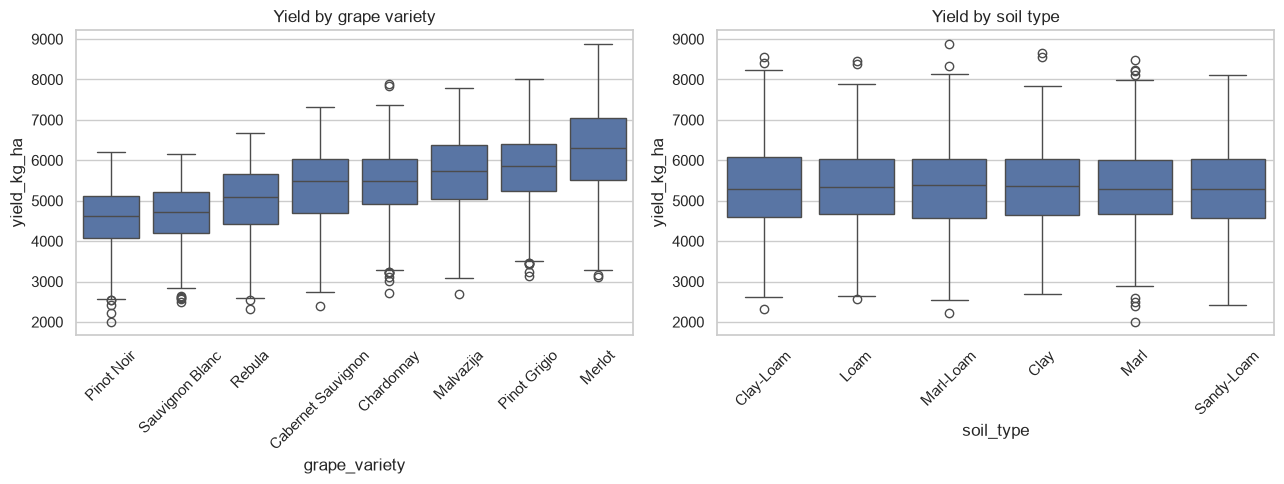

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = df.groupby("grape_variety")["yield_kg_ha"].median().sort_values().index
sns.boxplot(data=df, x="grape_variety", y="yield_kg_ha", order=order, ax=axes[0])
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("Yield by grape variety")

sns.boxplot(data=df, x="soil_type", y="yield_kg_ha", ax=axes[1])
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("Yield by soil type")

plt.tight_layout()
plt.show()


## 10. Summary — proposed feature set for Phase 2

**Targets**
- Classification: `harvest_category`
- Regression: `yield_kg_ha`

**Excluded — leakage (computed from, or only knowable after, the outcome)**
`harvest_doy`, `harvest_date`, `yield_category`, `gbai_score`, `ln_quality_index`,
`est_price_eur`, `vintage_quality`, `climate_risk`, `harvest_rainfall_mm`,
`autumn_rainfall_mm`, `annual_rainfall_mm`

**Excluded — redundant or degenerate**
`grape_color` (fully determined by `grape_variety`), `vintage_age_years` (disguised,
non-reusable transform of `year`)

**Kept — candidate feature set**
- Identifiers/categoricals: `grape_variety`, `soil_type`, `location`, `year`
- Vineyard: `elevation_m`, `vine_age_years`
- Weather (pre-harvest window only): `avg_temperature_C`, `min_spring_temp_C`,
  `growing_season_temp_C`, `temp_deviation_C`, `summer_heat_days`, `spring_frost_days`,
  `growing_degree_days`, `winter_rainfall_mm`, `spring_rainfall_mm`,
  `summer_rainfall_mm`, `rainfall_deviation_mm`, `humidity_pct`, `sunshine_hours`,
  `soil_moisture_pct`, `heat_frost_ratio`
- History: `prev_harvest_doy`, `prev_yield_kg_ha` (needs imputation)

This list is a **proposal**, not final — Phase 2 (cleaning & feature engineering) will
implement it inside a `ColumnTransformer` so the exact same transformation applies at
training and prediction time.
